# 03 - Matchup Dataset and XGBoost Model

Turns the season table into one row per game (home team vs away team), where each feature is
the *difference* between the two teams, then tunes and trains the win-probability classifier.

**Input:** `processed_data/games_2022_processed.csv`, `processed_data/team_agg.csv`
**Output:** `processed_data/xgb_win_model.json`

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
)

In [ ]:
from pathlib import Path

# Works whether the notebook is launched from the repo root or from notebooks/.
REPO_ROOT = Path.cwd() if (Path.cwd() / "COMPETITION_DATA").exists() else Path.cwd().parent
DATA_DIR = REPO_ROOT / "COMPETITION_DATA"
PROCESSED_DIR = REPO_ROOT / "processed_data"
PROCESSED_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", None)

In [ ]:
games_2022 = pd.read_csv(PROCESSED_DIR / "games_2022_processed.csv")
team_agg = pd.read_csv(PROCESSED_DIR / "team_agg.csv")

print(games_2022.shape, team_agg.shape)

## Building the matchup table

Home and away rows of the same `game_id` are joined side by side, each team's season averages
are attached, and every feature is reduced to a home-minus-away difference.

In [21]:
games_home = games_2022[games_2022["home_away"] == "home"][["game_id", "team", "win"]].rename(columns={"team": "team_home", "win": "win_home"})
games_away = games_2022[games_2022["home_away"] == "away"][["game_id", "team", "win"]].rename(columns={"team": "team_away", "win": "win_away"})

In [23]:
matchups = pd.merge(games_home, games_away, on="game_id")

features = ['win_percentage', 'team_score_mean', 'fg_pct_2_mean', 'fg_pct_3_mean',
            'ft_pct_mean', 'AST_mean', 'BLK_mean', 'STL_mean', 'TOV_mean', 'point_diff_mean', 'elo_rating']

In [24]:
matchups = matchups.merge(team_agg[['team'] + features], left_on='team_home', right_on='team', how='left') \
                   .drop("team", axis=1) \
                   .rename(columns={f: f"{f}_home" for f in features})

matchups = matchups.merge(team_agg[['team'] + features], left_on='team_away', right_on='team', how='left') \
                   .drop("team", axis=1) \
                   .rename(columns={f: f"{f}_away" for f in features})

In [25]:
for f in features:
    matchups[f + "_diff"] = matchups[f + "_home"] - matchups[f + "_away"]

In [26]:
X = matchups[[f + "_diff" for f in features]]
y = matchups["win_home"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
matchups

,game_id,team_home,win_home,team_away,win_away,win_percentage_home,team_score_mean_home,fg_pct_2_mean_home,fg_pct_3_mean_home,ft_pct_mean_home,AST_mean_home,BLK_mean_home,STL_mean_home,TOV_mean_home,point_diff_mean_home,elo_rating_home,win_percentage_away,team_score_mean_away,fg_pct_2_mean_away,fg_pct_3_mean_away,ft_pct_mean_away,AST_mean_away,BLK_mean_away,STL_mean_away,TOV_mean_away,point_diff_mean_away,elo_rating_away,win_percentage_diff,team_score_mean_diff,fg_pct_2_mean_diff,fg_pct_3_mean_diff,ft_pct_mean_diff,AST_mean_diff,BLK_mean_diff,STL_mean_diff,TOV_mean_diff,point_diff_mean_diff,elo_rating_diff
0,game_2022_2012,south_carolina_gamecocks,0,missouri_tigers,1,0.935484,0.441966,0.476529,0.315578,0.676142,0.366487,0.712499,0.232975,0.308419,0.183298,1707.349408,0.600000,0.432710,0.495239,0.372334,0.733970,0.345370,0.314494,0.206173,0.310569,0.031464,1558.831125,0.335484,0.009255,-0.018710,-0.056755,-0.057828,0.021117,0.398005,0.026802,-0.002151,0.151834,148.518283
1,game_2022_2013,tennessee_lady_volunteers,1,alabama_crimson_tide,0,0.741935,0.429304,0.451456,0.298011,0.635182,0.379032,0.619714,0.232975,0.370574,0.091046,1612.607377,0.566667,0.434891,0.467527,0.335122,0.708576,0.283333,0.434958,0.329630,0.321951,0.050467,1538.504564,0.175269,-0.005587,-0.016071,-0.037111,-0.073394,0.095699,0.184756,-0.096655,0.048623,0.040579,74.102812
2,game_2022_2111,auburn_tigers,0,alabama_crimson_tide,1,0.357143,0.371162,0.420752,0.279180,0.651444,0.283730,0.470657,0.313492,0.316202,-0.020360,1452.245432,0.566667,0.434891,0.467527,0.335122,0.708576,0.283333,0.434958,0.329630,0.321951,0.050467,1538.504564,-0.209524,-0.063729,-0.046775,-0.055941,-0.057131,0.000397,0.035699,-0.016138,-0.005749,-0.070828,-86.259132
3,game_2022_2112,tennessee_lady_volunteers,1,arkansas_razorbacks,0,0.741935,0.429304,0.451456,0.298011,0.635182,0.379032,0.619714,0.232975,0.370574,0.091046,1612.607377,0.580645,0.464878,0.467804,0.323014,0.676956,0.326165,0.571328,0.272401,0.226593,0.075068,1547.065532,0.161290,-0.035574,-0.016348,-0.025003,-0.041774,0.052867,0.048386,-0.039427,0.143981,0.015978,65.541845
4,game_2022_2113,georgia_lady_bulldogs,1,florida_gators,0,0.678571,0.422897,0.461190,0.313506,0.739002,0.425595,0.640540,0.317460,0.344077,0.094793,1590.213184,0.677419,0.416039,0.449667,0.302377,0.733578,0.322581,0.442159,0.328554,0.361133,0.036479,1590.688094,0.001152,0.006859,0.011524,0.011128,0.005424,0.103015,0.198382,-0.011094,-0.017056,0.058314,-0.474910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2509,game_2022_4442,detroit_mercy_titans,0,cleveland_state_vikings,1,0.037037,0.292835,0.407079,0.262656,0.655214,0.276749,0.373759,0.334705,0.433604,-0.125995,1319.290953,0.680000,0.410467,0.443847,0.300088,0.702101,0.278889,0.497782,0.348148,0.356098,0.068411,1563.999231,-0.642963,-0.117632,-0.036768,-0.037433,-0.046886,-0.002140,-0.124024,-0.013443,0.077507,-0.194406,-244.708278
2510,game_2022_4859,binghamton_bearcats,1,umbc_retrievers,0,0.269231,0.303379,0.443587,0.278234,0.739119,0.302350,0.407946,0.245014,0.337711,-0.023724,1404.660065,0.080000,0.272150,0.393031,0.297315,0.710628,0.236667,0.180511,0.287407,0.362927,-0.126355,1340.586805,0.189231,0.031229,0.050556,-0.019081,0.028492,0.065684,0.227435,-0.042393,-0.025216,0.102631,64.073260
2511,game_2022_4786,western_illinois_leathernecks,0,south_dakota_coyotes,1,0.444444,0.414330,0.478781,0.311097,0.635103,0.316872,0.461720,0.285322,0.311653,-0.049152,1479.599207,0.827586,0.423783,0.492593,0.331312,0.750942,0.362069,0.467719,0.329502,0.202691,0.146310,1624.175728,-0.383142,-0.009453,-0.013812,-0.020215,-0.115839,-0.045197,-0.005999,-0.044180,0.108962,-0.195462,-144.576521
2512,game_2022_4795,xavier_musketeers,0,seton_hall_pirates,1,0.300000,0.358255,0.419886,0.261187,0.734109,0.329630,0.399384,0.277778,0.350407,-0.098131,1411.287579,0.612903,0.423274,0.462575,0.337344,0.761860,0.400538,0.464570,

# XGBoost For Winning Probability Prediction

## Hyperparameter tuning

In [33]:
# Hyperparmeter tuning

xgb_model = xgb.XGBClassifier(objective='binary:logistic', booster='gbtree', seed=42)

param_grid = {
    'learning_rate': [0.1, 0.3],
    'max_depth': [5, 9],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.5, 0.8],
    'n_estimators': [100, 150]
}

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring='roc_auc', cv=3, verbose=1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best auc:", grid_search.best_score_)


Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.6}
Best auc: 0.8375298651638919


> **Note:** the training cell below uses `subsample=0.8` and `colsample_bytree=0.8`, while the
> grid search above selected `0.6` and `0.5`. The original competition model was trained with
> the values shown below, so they are kept as-is here.

## Training with early stopping

In [34]:
params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'eta': 0.1,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_test, label=y_test)

evals = [(dtrain, 'train'), (dval, 'eval')]

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=100,
    evals=evals,
    early_stopping_rounds=10, # pruning
    verbose_eval=True
)

[0]	train-auc:0.86974	eval-auc:0.85676
[1]	train-auc:0.89325	eval-auc:0.87434
[2]	train-auc:0.89646	eval-auc:0.87907
[3]	train-auc:0.89967	eval-auc:0.88147
[4]	train-auc:0.90155	eval-auc:0.87886
[5]	train-auc:0.90453	eval-auc:0.87930
[6]	train-auc:0.90658	eval-auc:0.88140
[7]	train-auc:0.90763	eval-auc:0.87985
[8]	train-auc:0.90814	eval-auc:0.88059
[9]	train-auc:0.90948	eval-auc:0.88042
[10]	train-auc:0.91063	eval-auc:0.88026
[11]	train-auc:0.91205	eval-auc:0.88016
[12]	train-auc:0.91251	eval-auc:0.88104
[13]	train-auc:0.91365	eval-auc:0.88043


## Evaluation

In [58]:
dtest = xgb.DMatrix(X_test)

y_pred_prob = model.predict(dtest)
y_pred = (y_pred_prob >= 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred)

auc_score = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc_score:.4f}")

Accuracy: 0.8032
AUC: 0.8804


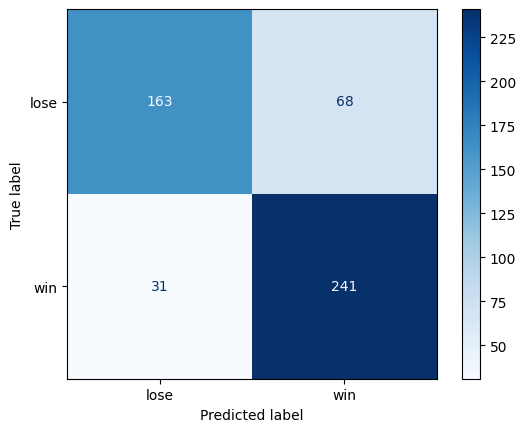

In [71]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    values_format="d",
    display_labels=["lose", "win"]
)

Gain-based feature importance - Elo and point differential carry the model:

In [39]:
importance = model.get_score(importance_type='gain')
importance

{'win_percentage_diff': 19.300548553466797,
 'team_score_mean_diff': 3.539820671081543,
 'fg_pct_2_mean_diff': 2.833904504776001,
 'fg_pct_3_mean_diff': 3.1168906688690186,
 'ft_pct_mean_diff': 3.804534912109375,
 'AST_mean_diff': 3.7206435203552246,
 'BLK_mean_diff': 2.9173696041107178,
 'STL_mean_diff': 2.853879690170288,
 'TOV_mean_diff': 3.294581174850464,
 'point_diff_mean_diff': 29.547000885009766,
 'elo_rating_diff': 41.99172592163086}

In [42]:
y_pred_prob = model.predict(dval)
y_pred = (y_pred_prob > 0.5).astype(int)

f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")
print(f"Recall Score: {recall:.4f}")


F1 Score: 0.8296
Recall Score: 0.8860


## Save the trained model

In [ ]:
model_path = PROCESSED_DIR / "xgb_win_model.json"
model.save_model(str(model_path))
print(f"Saved model to {model_path}")